In [2]:
# Cell 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [6]:
# Cell 2 — Load the data
df = pd.read_csv(r'C:\Users\hp1\house-price-predictor\data\train.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
# Cell 3 — Explore the data
print("Basic Statistics:")
print(df.describe())

print("\nMissing values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Basic Statistics:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.06620

In [8]:
# Cell 4 — Select features and clean data
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'OverallQual', 'TotalBsmtSF', 'GarageCars']

X = df[features].fillna(df[features].median())
y = df['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nAny missing values left?", X.isnull().sum().sum())
print("\nSample of features:")
X.head()

Features shape: (1460, 7)
Target shape: (1460,)

Any missing values left? 0

Sample of features:


,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,OverallQual,TotalBsmtSF,GarageCars
0,1710,3,2,2003,7,856,2
1,1262,3,2,1976,6,1262,2
2,1786,3,2,2001,7,920,2
3,1717,3,1,1915,7,756,3
4,2198,4,2,2000,8,1145,3


In [12]:
# Cell 5 — Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Training set size : ", X_train.shape)
print("Testing set size: ", X_test.shape)
print("\nSo we train on", X_train.shape[0], "houses")
print("Ans test on ", X_test.shape[0], "houses")


Training set size :  (1168, 7)
Testing set size:  (292, 7)

So we train on 1168 houses
Ans test on  292 houses


In [18]:
# Cell 6 — Train the model
model = RandomForestRegressor(n_estimators=400, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print("\nModel Details:")
print("- Algorithm: Random Forest Regressor")
print("- Number of trees:", model.n_estimators)
print("- Features used:", features)

✅ Model trained successfully!

Model Details:
- Algorithm: Random Forest Regressor
- Number of trees: 400
- Features used: ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'OverallQual', 'TotalBsmtSF', 'GarageCars']


In [19]:
# Cell 7 — Test the model
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
accuracy = 100 - (mae / y_test.mean()*100)


print("Model Performance : " )
print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"Average house price in dataset: ${y_test.mean():,.0f}")
print(f"Approximate Accuracy: {accuracy:.1f}%")
print(f"\nOn average, our model's prediction is off by ${mae:,.0f}")


Model Performance : 
Mean Absolute Error: $18,846
Average house price in dataset: $178,840
Approximate Accuracy: 89.5%

On average, our model's prediction is off by $18,846


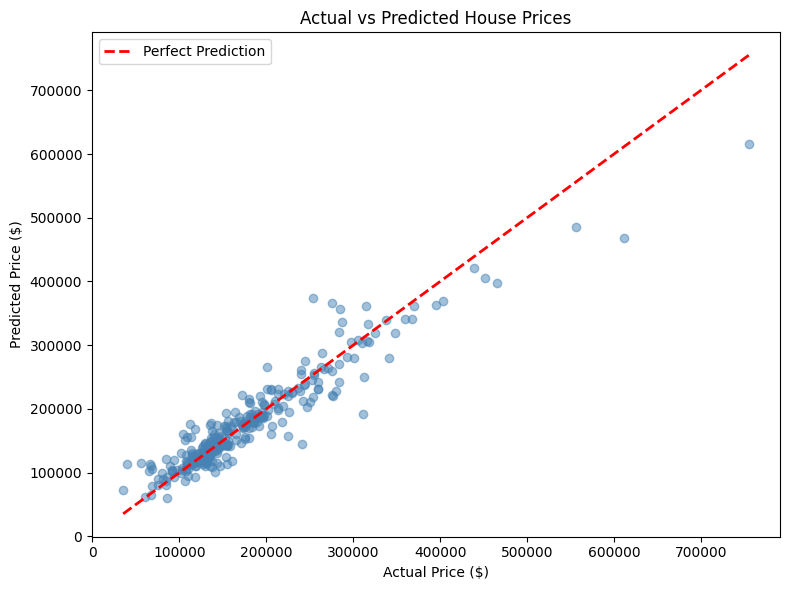

✅ Chart saved!


In [26]:
# Cell 8 — Visualise results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($)', fontsize=10)
plt.ylabel('Predicted Price ($)', fontsize=10)
plt.title('Actual vs Predicted House Prices', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../actual_vs_predicted.png')
plt.show()

print("✅ Chart saved!")


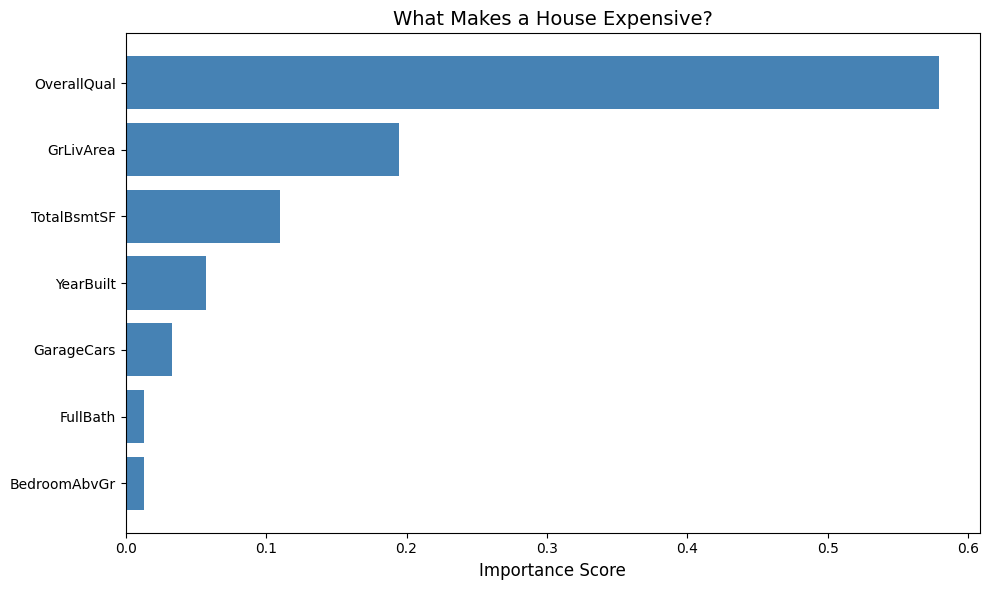


Feature Rankings:
OverallQual: 0.579
GrLivArea: 0.195
TotalBsmtSF: 0.110
YearBuilt: 0.057
GarageCars: 0.033
FullBath: 0.013
BedroomAbvGr: 0.013


In [28]:
# Cell 9 — Feature Importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='steelblue')

plt.xlabel('Importance Score', fontsize=12)
plt.title('What Makes a House Expensive?', fontsize=14)
plt.tight_layout()
plt.savefig('../feature_importance.png')
plt.show()

print("\nFeature Rankings:")
for i, row in feature_importance.sort_values('Importance', ascending=False).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.3f}")

In [34]:
# Cell 10 — Predict your own house price!
def predict_house_price(area, bedrooms, bathrooms, year_built, quality, basement, garage):
    """
    Predict house price based on features
    
    area       → Total living area in sqft
    bedrooms   → Number of bedrooms
    bathrooms  → Number of full bathrooms
    year_built → Year the house was built
    quality    → Overall quality (1-10, where 10 is best)
    basement   → Basement area in sqft
    garage     → Number of cars garage can hold
    """
    input_data = pd.DataFrame({
        'GrLivArea': [area],
        'BedroomAbvGr': [bedrooms],
        'FullBath': [bathrooms],
        'YearBuilt': [year_built],
        'OverallQual': [quality],
        'TotalBsmtSF': [basement],
        'GarageCars': [garage]
    })
    
    price = model.predict(input_data)[0]
    
    print("=" * 40)
    print("🏠 HOUSE PRICE PREDICTOR")
    print("=" * 40)
    print(f"📐 Living Area    : {area} sqft")
    print(f"🛏️  Bedrooms       : {bedrooms}")
    print(f"🛁 Bathrooms      : {bathrooms}")
    print(f"📅 Year Built     : {year_built}")
    print(f"⭐ Quality (1-10) : {quality}")
    print(f"🏚️  Basement Area  : {basement} sqft")
    print(f"🚗 Garage Cars    : {garage}")
    print("=" * 40)
    print(f"💰 Predicted Price: ${price:,.0f}")
    print("=" * 40)

# Try it out!
predict_house_price(
    area=1000,
    bedrooms=3,
    bathrooms=2,
    year_built=2005,
    quality=4,
    basement=800,
    garage=2
), 

predict_house_price(
    area=1700,
    bedrooms=4,
    bathrooms=2,
    year_built=2020,
    quality=9,
    basement=850,
    garage=3
)


    

🏠 HOUSE PRICE PREDICTOR
📐 Living Area    : 1000 sqft
🛏️  Bedrooms       : 3
🛁 Bathrooms      : 2
📅 Year Built     : 2005
⭐ Quality (1-10) : 4
🏚️  Basement Area  : 800 sqft
🚗 Garage Cars    : 2
💰 Predicted Price: $131,980
🏠 HOUSE PRICE PREDICTOR
📐 Living Area    : 1700 sqft
🛏️  Bedrooms       : 4
🛁 Bathrooms      : 2
📅 Year Built     : 2020
⭐ Quality (1-10) : 9
🏚️  Basement Area  : 850 sqft
🚗 Garage Cars    : 3
💰 Predicted Price: $301,943
